# T12 — Retrodeforming a global lithospheric-thickness grid through deep time

*Based on:* the Afonso et al. (2019) present-day lithospheric-thickness grid (LITMOD inversion, hosted on the GPlates Portal) reconstructed via Zahirovic et al. (2022) deforming-network kinematics. Pure-shear thickness scaling follows McKenzie (1978).

**Take the Afonso 2019 lithospheric-thickness grid, push every cell backward through the Zahirovic 2022 deforming-network history (rigid rotation + strain-accumulating deforming meshes), apply McKenzie pure-shear volume conservation to update thickness through time, and write a stack of paleo-thickness NetCDFs at 10 Myr cadence back to 250 Ma — intended as time-dependent boundary conditions for mantle-convection models.**

## Reference frame — MANTLE frame (anchor 0)

This notebook intentionally uses the **mantle (no-net-rotation) reference frame** (`ANCHOR_PLATE_ID = 0`). The output is a time series of paleo-lithospheric-thickness grids designed to be ingested by mantle-flow simulations, which run in the mantle reference frame. **Do not use these grids for paleoclimate / paleomagnetic comparison work** — for that, re-run with `ANCHOR_PLATE_ID = 701701` (the paleomag-frame anchor in Z22) per the house rule.

## What this notebook produces

- A stack of paleo-LAB NetCDFs at `0, 10, 20, ..., 250 Ma`, on a regular 1° × 1° global grid, written to `outputs/paleo_lithospheric_thickness/paleo_LAB_<t>Ma.nc`. The 250 Ma cutoff matches Zahirovic 2022's deforming-network coverage — pre-250 Ma rigid-extension is offered as an *Extend this* option at the bottom. **Scope is continental crust only.** Oceanic crust is dropped at the sampling step (continental crust is the only material that passes through Z22's deforming meshes; oceans don't deform, so retrodeforming them with this kinematic recipe adds no information and would need a separate physical model — see *Extend this* for the half-space cooling oceanic-fill option). Output cells over present-day oceans are masked to NaN.
- A 4-snapshot pyGMT triptych (0 / 80 / 160 / 250 Ma) showing the time-evolution of the thickness field, with the deforming-network outline overlaid in orange.
- A reusable inline helper (`retrodeform_thickness(...)`) that can be applied to any other present-day lithospheric property (e.g. heat flow, crustal thickness) by swapping the input grid.

## Audience and difficulty

**Audience:** postgrad / researcher. **Difficulty:** ★★★ (deformation kinematics + property retrodeformation; expects familiarity with finite-strain conventions).

## Learning objectives

- Build a `pygplates.TopologicalModel` from a deforming-plate-network plate model and call `reconstruct_geometry(...)` to track points back through time with cumulative strain.
- Extract the per-point deformation gradient from accumulated strain and apply pure-shear volume conservation to update a scalar lithospheric property.
- Resample irregular reconstructed points back to a regular paleo lat/lon grid for use as a model boundary condition.

## Prerequisites and runtime

- Plate model: Zahirovic et al. (2022), fetched via `plate_model_manager`.
- Python: `gplately`, `pygmt`, `pygplates>=1.0` (for `TopologicalModel.reconstruct_geometry` + `get_strains`), `numpy`, `xarray`, `scipy`.
- Source grid: `data/lithospheric_thickness_Afonso2019.nc` (bundled with this repo; Afonso et al. 2019 LITMOD inversion).
- Runtime: ~5–10 minutes for 26 snapshots at 1° output resolution; scales with grid resolution.


## Data availability

| Asset | Provenance | Where to get it |
|---|---|---|
| Afonso 2019 lithospheric thickness | Afonso, J.C. et al. (2019), *Tectonophysics* 757, 198-215 (LITMOD inversion) | Bundled at `data/lithospheric_thickness_Afonso2019.nc`. Also available from the [GPlates Portal](https://portal.gplates.org/). |
| **Zahirovic2022** plate model (rotation + topologies + static polygons) | EarthByte | Auto-downloaded by `plate_model_manager`. |


In [1]:
# Defensive cwd fix — works whether Jupyter launched from the repo root
# or from inside Notebooks/. The notebook references data/, outputs/ etc.
# relative to the repo root.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports and version probe
import os, sys, math
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from scipy.spatial import cKDTree
from IPython.display import display, HTML
print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME          = "Zahirovic2022"              # deforming-network model
ANCHOR_PLATE_ID     = 0                            # MANTLE frame — see header note
TIME_RANGE_MA       = (0.0, 250.0, 10.0)           # (youngest, oldest, step) Ma — Z22 deforming-mesh era
SOURCE_GRID         = "data/lithospheric_thickness_Afonso2019.nc"
SOURCE_VAR          = "z"                          # variable name in the NC
SOURCE_UNIT_SCALE   = 1e-3                         # metres → kilometres (display)
SAMPLE_SPACING_DEG  = 2.0                          # grid sampling for retrodeformation
OUTPUT_SPACING_DEG  = 1.0                          # regular paleo-grid output resolution
OUTPUT_DIR          = Path("outputs/paleo_lithospheric_thickness")
DET_F_CLAMP         = (0.2, 3.0)                   # secondary cap on the deformation ratio (pure-shear sanity)
OUTPUT_THICKNESS_CLAMP_KM = (10.0, 250.0)          # primary physical cap on retrodeformed LAB thickness (km); values >250 clamped to 250
# Spherical-IDW interpolation knobs (KD-tree on unit sphere; antimeridian-safe)
IDW_K               = 8                            # nearest-neighbour count
IDW_MAX_DIST_DEG    = 4.0                          # neighbour cap (degrees of great-circle)
IDW_POWER           = 2.0                          # inverse-distance power
SNAPSHOT_TIMES_FIG  = (0.0, 80.0, 160.0, 250.0)    # one snapshot at each end + two intermediate inside the deforming-mesh era
# ============================================================================
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"  output dir: {OUTPUT_DIR.resolve()}")


  output dir: /Users/dietmar/Documents/GPlates/GPlately-pyGMT_tutorials/outputs/paleo_lithospheric_thickness


## 1. Load and inspect the Afonso 2019 lithospheric-thickness grid

Lithospheric thickness here is the LAB (lithosphere–asthenosphere boundary) depth from the Afonso et al. (2019) LITMOD inversion of joint seismic + gravity + thermal data. Continental values are typically 100–250 km (thick cratonic keels up to 300 km), oceanic values 30–100 km that thicken with seafloor age.


  Afonso 2019 grid: shape=(721, 1441)  lon=-179.9 → 179.9  lat=-89.9 → 89.9  range=18.6 – 246.8 km


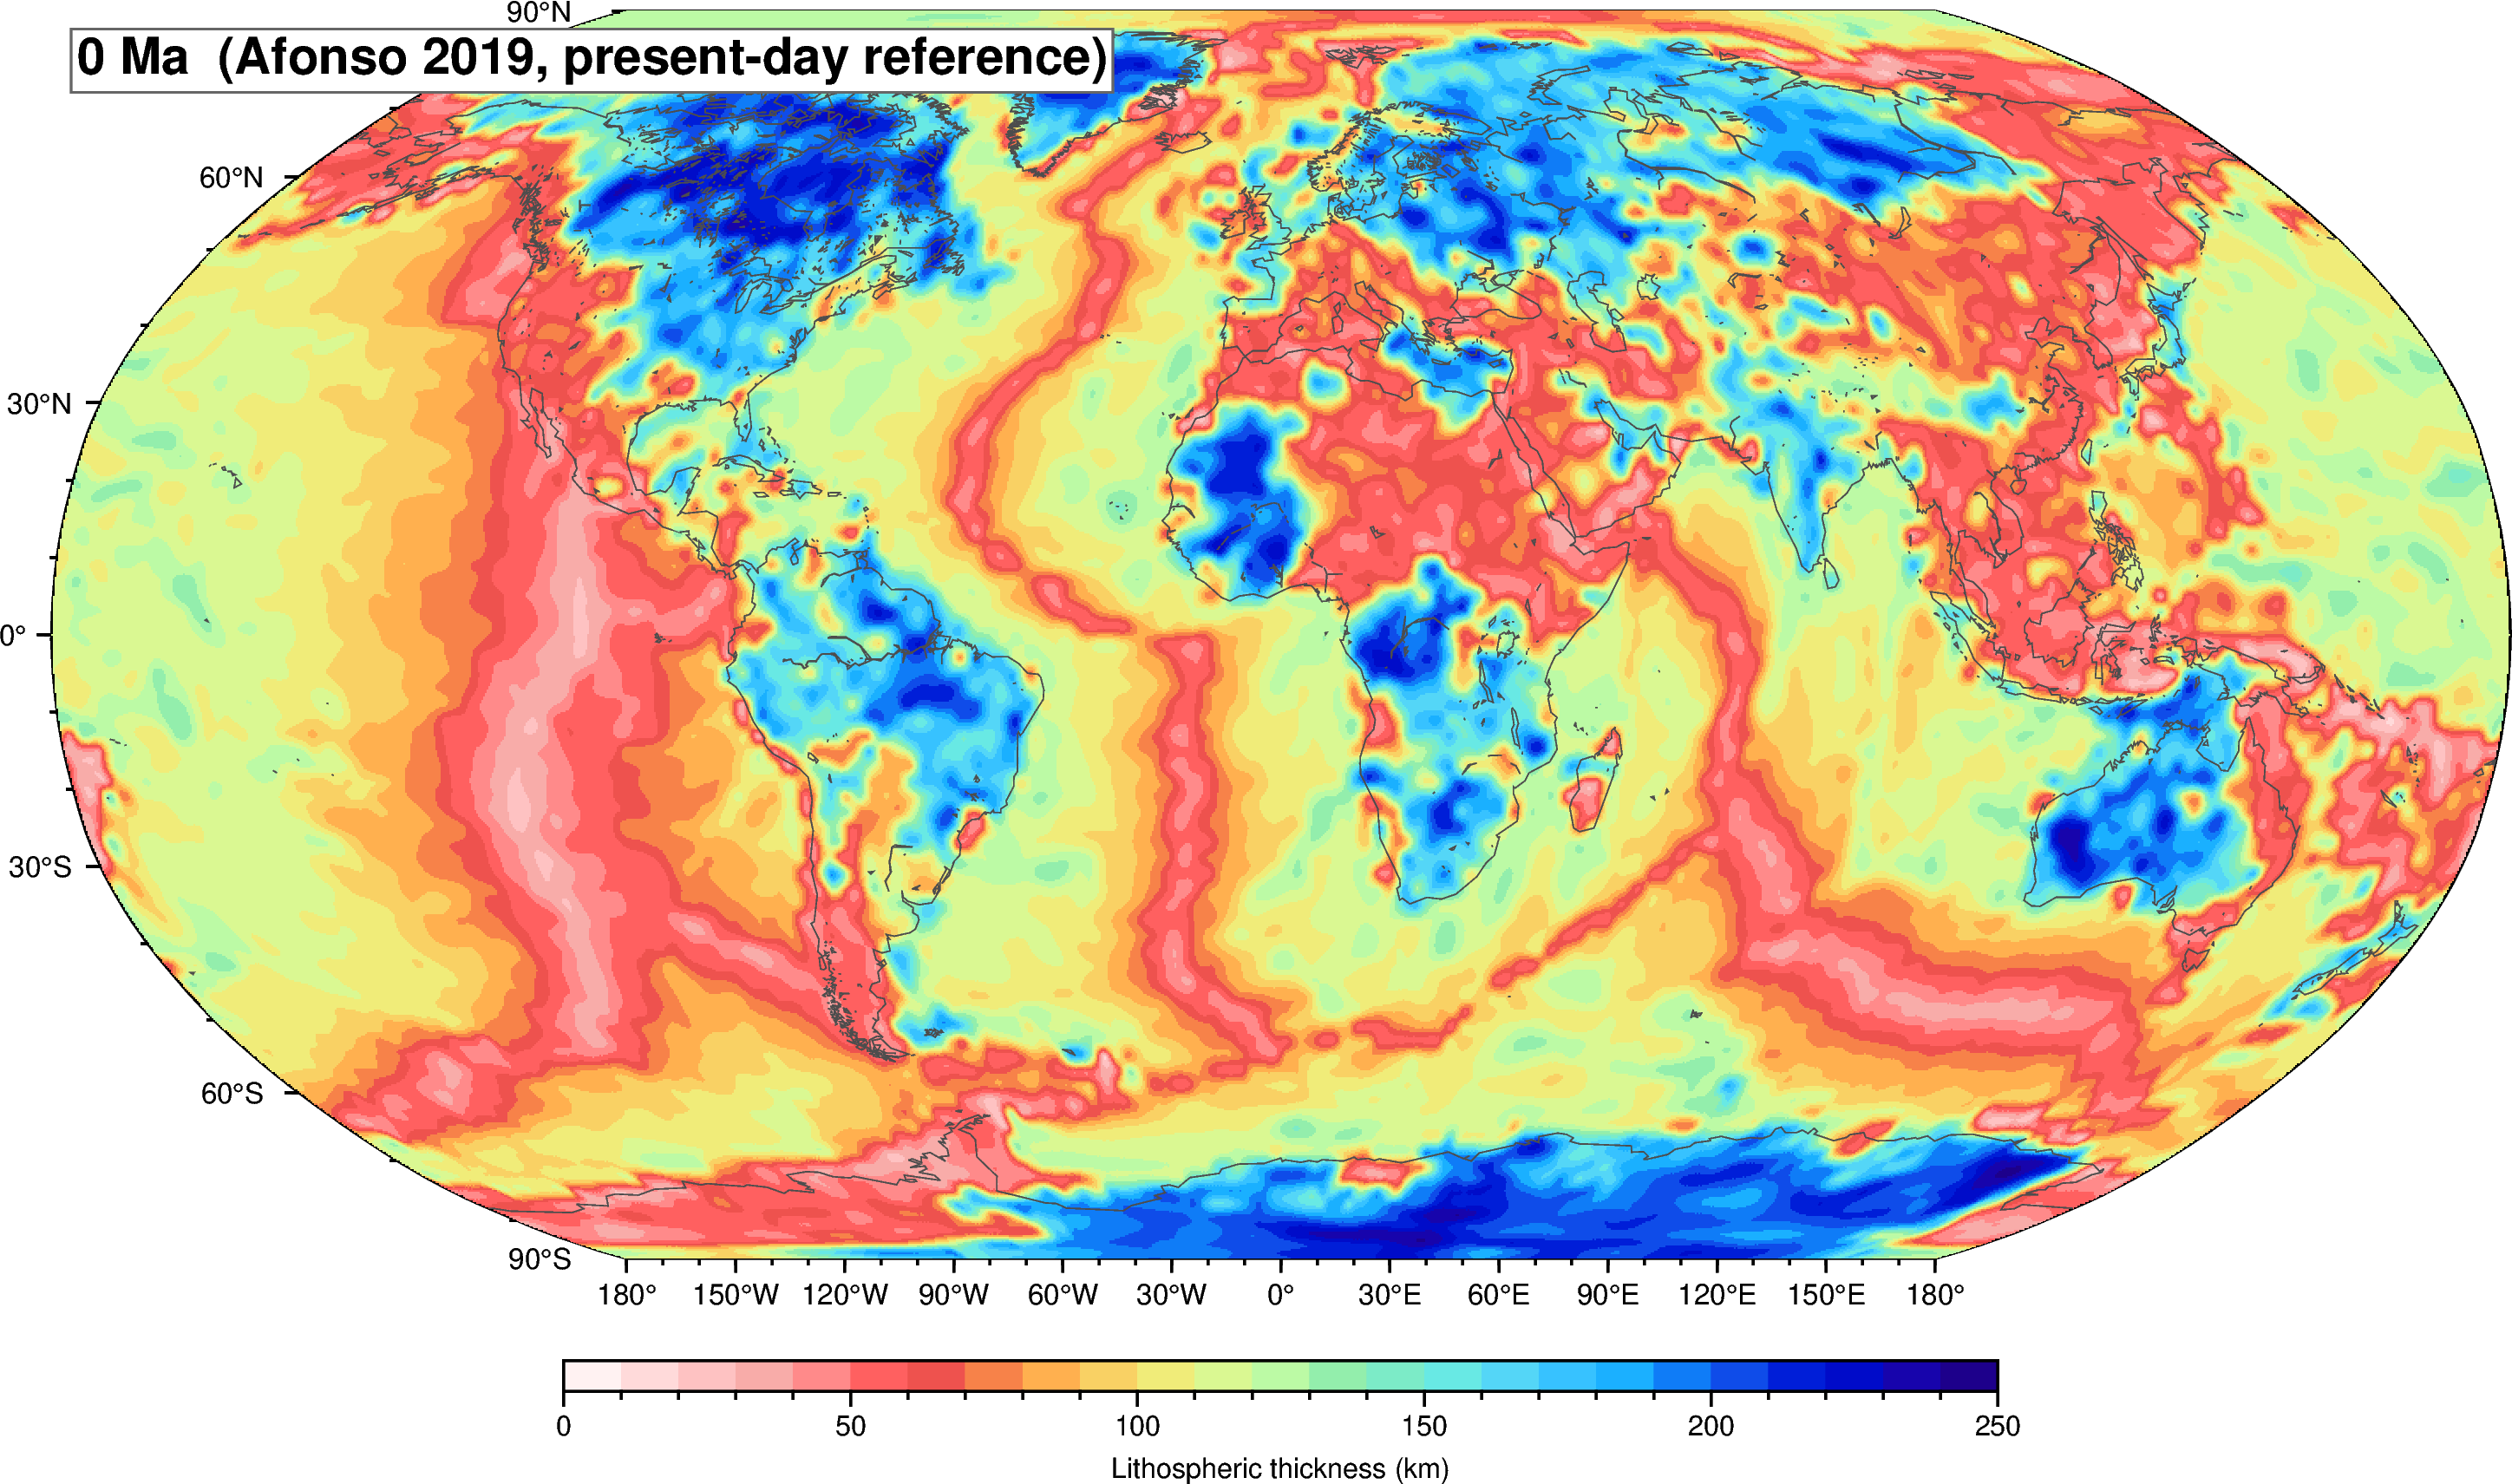

In [3]:
# Cell 2 — load Afonso 2019 grid; build a quick present-day reference figure
src = Path(SOURCE_GRID)
if not src.exists():
    raise FileNotFoundError(
        f"Afonso 2019 lithospheric-thickness grid not found at {src}.\n"
        "Bundled with the suite — verify the data/ directory was checked out.")
ds_in = xr.open_dataset(src)
thk_now_km = ds_in[SOURCE_VAR] * SOURCE_UNIT_SCALE          # metres → km
thk_now_km = thk_now_km.rename({thk_now_km.dims[0]: "lat", thk_now_km.dims[1]: "lon"})
thk_now_km.attrs["long_name"] = "Present-day lithospheric thickness (Afonso 2019)"
thk_now_km.attrs["units"] = "km"
print(f"  Afonso 2019 grid: shape={thk_now_km.shape}  "
      f"lon={float(thk_now_km.lon.min()):.1f} → {float(thk_now_km.lon.max()):.1f}  "
      f"lat={float(thk_now_km.lat.min()):.1f} → {float(thk_now_km.lat.max()):.1f}  "
      f"range={float(thk_now_km.min()):.1f} – {float(thk_now_km.max()):.1f} km")

# Present-day quick-look (pyGMT)
pygmt.makecpt(cmap="haxby", series=[0, 250, 10], reverse=True)
fig = pygmt.Figure()
fig.basemap(region="d", projection="N0/24c", frame=["af"])
fig.grdimage(grid=thk_now_km, cmap=True, nan_transparent=True)
fig.coast(shorelines="0.3p,gray30")
fig.colorbar(position="JBC+w14c/0.3c+h+o0/1.0c",
             frame=["af", "x+lLithospheric thickness (km)"])
fig.text(text="0 Ma  (Afonso 2019, present-day reference)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1200)


## 2. Build the Zahirovic 2022 topological model + reconstruct grid points

`pygplates.TopologicalModel` (pygplates ≥ 1.0) is the modern API for deformation-aware point tracking. Calling `reconstruct_geometry(...)` on a point set returns a time-span object that contains, for every requested time, both the past lon/lat of each point AND the accumulated strain tensor experienced by the point's material between that time and the present.

We sample the present-day Afonso grid onto a regular `SAMPLE_SPACING_DEG` lattice (default 2°). At 2° the global grid is ~16,000 points — large enough to capture continental detail but coarse enough that `reconstruct_geometry` runs in seconds rather than minutes.


In [4]:
# Cell 3 — build topological model; sample present-day grid; drop oceanic
# points (continental-only scope — oceanic crust does not pass through Z22's
# deforming meshes so retrodeforming it adds nothing pedagogically AND would
# need a separate physical model, e.g. age-dependent half-space cooling).
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
topo_model = pygplates.TopologicalModel(
    model.get_topologies(),
    model.get_rotation_model(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)
print(f"  TopologicalModel built — anchor plate {ANCHOR_PLATE_ID} (mantle frame)")

# Sample the source grid onto a regular SAMPLE_SPACING_DEG lattice
lons_s = np.arange(-180, 180 + 1e-9, SAMPLE_SPACING_DEG)
lats_s = np.arange(-90,   90 + 1e-9, SAMPLE_SPACING_DEG)
LON, LAT = np.meshgrid(lons_s, lats_s)
sample_lon = LON.ravel()
sample_lat = LAT.ravel()
sample_thk = thk_now_km.interp(lon=("p", sample_lon), lat=("p", sample_lat)).values
finite = np.isfinite(sample_thk)
sample_lon = sample_lon[finite]
sample_lat = sample_lat[finite]
sample_thk = sample_thk[finite]
n_total = len(sample_thk)
print(f"  raw sample: {n_total:,} present-day grid points at {SAMPLE_SPACING_DEG}° spacing")

# ----- Drop oceanic samples using the PMM present-day AgeGrid -----
# Any point whose present-day seafloor age is finite is oceanic crust.
def _open_age_grid(pmm_model, t):
    """Return an xarray DataArray of seafloor age (Ma) at time t, or None."""
    for meth in ("get_raster", "get_layer"):
        fn = getattr(pmm_model, meth, None)
        if fn is None:
            continue
        try:
            result = fn("AgeGrids", time=float(t))
        except Exception:
            continue
        if result is None:
            continue
        if isinstance(result, (list, tuple)):
            result = result[0] if result else None
        if isinstance(result, str):
            try:
                ds = xr.open_dataset(result)
                var = next((v for v in ds.data_vars
                            if v.lower() in ("z","age","seafloor_age")),
                           list(ds.data_vars)[0])
                return ds[var].rename({ds[var].dims[0]: "lat", ds[var].dims[1]: "lon"})
            except Exception:
                continue
        if hasattr(result, "interp"):
            return result
    return None

age_grid_now = _open_age_grid(model, 0.0)
if age_grid_now is not None:
    sample_age = age_grid_now.interp(lon=("p", sample_lon),
                                     lat=("p", sample_lat)).values
    continental = ~np.isfinite(sample_age)         # True where NO seafloor age = continent
    sample_lon = sample_lon[continental]
    sample_lat = sample_lat[continental]
    sample_thk = sample_thk[continental]
    n_oceanic_dropped = int(np.isfinite(sample_age).sum())
    print(f"  dropped {n_oceanic_dropped:,} oceanic points via present-day PMM AgeGrid")
    print(f"  kept {len(sample_thk):,} continental points for retrodeformation")
else:
    print(f"  ⚠ no AgeGrid available for {MODEL_NAME} — continuing with all points (oceans WILL appear in output)")

# Build pygplates point geometry + initial-scalars dict for retrodeformation.
# pygplates does the McKenzie pure-shear volume conservation internally when we
# attach the present-day thickness as gpml_crustal_thickness — calling
# ReconstructedGeometryTimeSpan.get_crustal_thicknesses(t) later returns the
# retrodeformed thickness at time t directly (in km).
point_geom = pygplates.MultiPointOnSphere(list(zip(sample_lat, sample_lon)))
initial_scalars = {
    pygplates.ScalarType.gpml_crustal_thickness: list(map(float, sample_thk)),
}


  TopologicalModel built — anchor plate 0 (mantle frame)
  raw sample: 15,931 present-day grid points at 2.0° spacing
  dropped 7,807 oceanic points via present-day PMM AgeGrid
  kept 8,124 continental points for retrodeformation


## 3. Reconstruct geometry + accumulate strain through time

`topo_model.reconstruct_geometry(...)` returns a `ReconstructedGeometryTimeSpan` object. From it we can ask:

- `get_geometry_points(time=t)` → past (lon, lat) of every point at time *t*
- `get_strains(time=t)` → accumulated 2D strain tensor at every point, integrated from the present back to *t*

Outside the deforming network the strain is identically zero (rigid rotation only); inside, the cumulative strain encodes the rifting / shortening history.


In [5]:
# Cell 4 — reconstruct continental points with attached present-day thicknesses.
# pygplates handles McKenzie pure-shear volume conservation internally; we just
# read out the per-snapshot retrodeformed thickness via get_crustal_thicknesses.
# Oceanic crust was already dropped in cell 3, so no further masking is needed.
clamp_lo, clamp_hi = DET_F_CLAMP
youngest, oldest, step = TIME_RANGE_MA
times = np.arange(youngest, oldest + 1e-9, step)
print(f"  reconstructing geometry over {youngest}–{oldest} Ma at {step} Myr step "
      f"({len(times)} snapshots), with attached gpml_crustal_thickness scalar")

# Continental retrodeformation: override pygplates' DefaultDeactivatePoints
# (which is tuned for forward reconstruction — it kills points that transition
# between plates going forward, modelling subduction). Going BACKWARD through
# time we want every continental sample to survive every step, otherwise huge
# parts of the continental output become NaN through deep time.
class _KeepAllPoints(pygplates.ReconstructedGeometryTimeSpan.DeactivatePoints):
    def __init__(self):
        super().__init__()
    def deactivate(self, *args, **kwargs):
        return False

time_span = topo_model.reconstruct_geometry(
    point_geom,
    initial_time=0.0,
    oldest_time=oldest,
    youngest_time=youngest,
    time_increment=step,
    initial_scalars=initial_scalars,
    deactivate_points=_KeepAllPoints(),     # see class doc above
)

snapshots = {}
deformation_summary = []   # filled per snapshot below; used for the time-series figure
for t in times:
    past_pts = time_span.get_geometry_points(t, return_inactive_points=True)
    past_thk = time_span.get_crustal_thicknesses(t, return_inactive_points=True)
    if past_pts is None or past_thk is None:
        snapshots[t] = None
        print(f"    t={t:5.0f} Ma — no active points")
        continue
    past_lats = np.array([p.to_lat_lon()[0] if p is not None else np.nan for p in past_pts])
    past_lons = np.array([p.to_lat_lon()[1] if p is not None else np.nan for p in past_pts])
    past_thk_a = np.array([v if v is not None else np.nan for v in past_thk])

    # Two-stage clamping:
    #   (a) ratio clamp — secondary guard against extreme deforming-mesh β,
    #       protects against unphysical pure-shear amplification before it
    #       multiplies a thick cratonic root.
    #   (b) absolute thickness clamp — primary physical cap; real LAB
    #       thickness on Earth ranges ~30–280 km even at peak orogens.
    ratio_raw  = past_thk_a / sample_thk
    ratio      = np.clip(ratio_raw, clamp_lo, clamp_hi)
    past_thk_clamped = np.clip(sample_thk * ratio,
                                OUTPUT_THICKNESS_CLAMP_KM[0],
                                OUTPUT_THICKNESS_CLAMP_KM[1])

    n_active = int(np.sum(np.isfinite(past_thk_clamped)))
    n_cap_lo = int(np.sum(past_thk_clamped == OUTPUT_THICKNESS_CLAMP_KM[0]))
    n_cap_hi = int(np.sum(past_thk_clamped == OUTPUT_THICKNESS_CLAMP_KM[1]))
    med = float(np.nanmedian(past_thk_clamped))
    mad = float(np.nanmedian(np.abs(past_thk_clamped - med)))

    # ----- Deformation-type summary (forward in time, i.e. from t → now) -----
    # ratio_raw > 1  → past was thicker than present  → THINNED since t  → EXTENSION
    # ratio_raw < 1  → past was thinner than present  → THICKENED since t → SHORTENING
    EXT_THR, SHORT_THR = 1.05, 0.95             # 5 % deformation cutoff
    ext_mask   = np.isfinite(ratio_raw) & (ratio_raw > EXT_THR)
    short_mask = np.isfinite(ratio_raw) & (ratio_raw < SHORT_THR)
    stable_mask= np.isfinite(ratio_raw) & ~(ext_mask | short_mask)
    n_ext, n_short, n_stab = int(ext_mask.sum()), int(short_mask.sum()), int(stable_mask.sum())
    beta_ext_med   = float(np.median(ratio_raw[ext_mask]))   if n_ext   else 1.0
    beta_short_med = float(np.median(ratio_raw[short_mask])) if n_short else 1.0
    # Total thinned / thickened km², measured as Δh × cell area;
    # cell area ∝ cos(lat) × (sample-spacing in radians)².  Constant prefactor
    # cancels out for the per-snapshot comparison, so we report the dimensionless
    # area-weighted sum of |Δh| in km·cos(lat).
    cos_lat       = np.cos(np.deg2rad(sample_lat))
    thinned_kmcos = float(np.sum((past_thk_a[ext_mask] - sample_thk[ext_mask])
                                  * cos_lat[ext_mask]))
    thickened_kmcos = float(np.sum((sample_thk[short_mask] - past_thk_a[short_mask])
                                    * cos_lat[short_mask]))

    print(f"    t={t:5.0f} Ma — {n_active:,} active continental points; "
          f"median thk = {med:.0f} km, MAD = {mad:.0f} km "
          f"(clamped at floor: {n_cap_lo}, ceiling: {n_cap_hi})")
    print(f"             ext:   {n_ext:>6,} cells  (β̃={beta_ext_med:.2f})   "
          f"Σ thinning   ≈ {thinned_kmcos:.0f}  km·cos(lat)")
    print(f"             short: {n_short:>6,} cells  (β̃={beta_short_med:.2f})   "
          f"Σ thickening ≈ {thickened_kmcos:.0f}  km·cos(lat)")
    print(f"             stable: {n_stab:>6,} cells  (|β-1| ≤ 5 %)")

    # Append to summary table
    deformation_summary.append({
        "t": float(t),
        "n_ext": n_ext, "n_short": n_short, "n_stable": n_stab,
        "frac_ext":   n_ext   / max(n_active, 1),
        "frac_short": n_short / max(n_active, 1),
        "beta_ext_med":   beta_ext_med,
        "beta_short_med": beta_short_med,
        "thinned_kmcos":   thinned_kmcos,
        "thickened_kmcos": thickened_kmcos,
    })

    snapshots[t] = dict(lat=past_lats, lon=past_lons, thk=past_thk_clamped)


  reconstructing geometry over 0.0–250.0 Ma at 10.0 Myr step (26 snapshots), with attached gpml_crustal_thickness scalar
    t=    0 Ma — 8,124 active continental points; median thk = 126 km, MAD = 52 km (clamped at floor: 0, ceiling: 0)
             ext:        0 cells  (β̃=1.00)   Σ thinning   ≈ 0  km·cos(lat)
             short:      0 cells  (β̃=1.00)   Σ thickening ≈ 0  km·cos(lat)
             stable:  8,124 cells  (|β-1| ≤ 5 %)
    t=   10 Ma — 8,124 active continental points; median thk = 128 km, MAD = 52 km (clamped at floor: 0, ceiling: 5)
             ext:      473 cells  (β̃=1.13)   Σ thinning   ≈ 11648  km·cos(lat)
             short:    256 cells  (β̃=0.84)   Σ thickening ≈ 4546  km·cos(lat)
             stable:  7,395 cells  (|β-1| ≤ 5 %)
    t=   20 Ma — 8,124 active continental points; median thk = 130 km, MAD = 53 km (clamped at floor: 0, ceiling: 21)
             ext:      630 cells  (β̃=1.26)   Σ thinning   ≈ 1172207  km·cos(lat)
             short:    358 cells  (β


## 4b. Continental deformation budget through time

Per-snapshot summary of *forward-in-time* deformation: extension (`β > 1.05`), shortening (`β < 0.95`) and stable continental crust. We plot the fraction of continental cells in each regime and the median stretching factor in each, so you can see at a glance which periods saw the most active rifting versus shortening through the last 250 Myr.


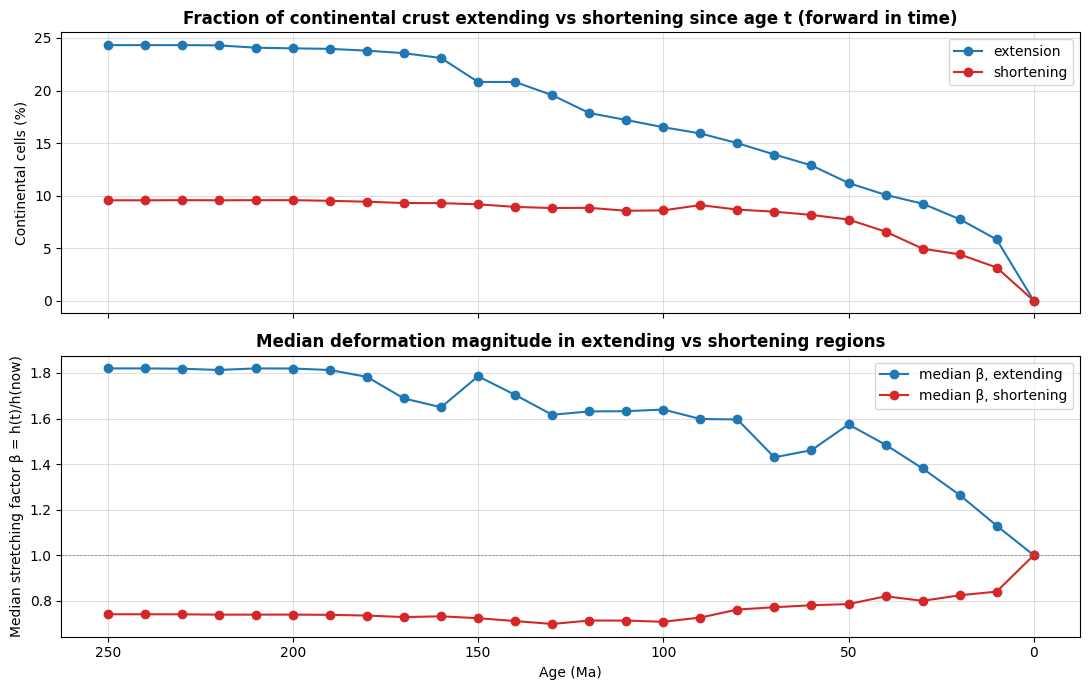

    t  n_ext  n_short  n_stable frac_ext frac_short beta_ext_med beta_short_med thinned_kmcos thickened_kmcos
  0.0      0        0      8124     0.0%       0.0%         1.00           1.00             0               0
 10.0    473      256      7395     5.8%       3.2%         1.13           0.84         11648            4546
 20.0    630      358      7136     7.8%       4.4%         1.26           0.82       1172207            7329
 30.0    750      402      6972     9.2%       4.9%         1.38           0.80       1341328            9093
 40.0    818      534      6772    10.1%       6.6%         1.48           0.82       1497420           10556
 50.0    910      627      6587    11.2%       7.7%         1.57           0.79       1522890           12176
 60.0   1046      663      6415    12.9%       8.2%         1.46           0.78       1584604           13012
 70.0   1130      688      6306    13.9%       8.5%         1.43           0.77       1571194           13363
 80.0   12

In [6]:
# Cell 5b — deformation budget through time
df_def = pd.DataFrame(deformation_summary).sort_values("t")
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax = axes[0]
ax.plot(df_def["t"], df_def["frac_ext"]   * 100, "o-", color="#1f77b4", label="extension")
ax.plot(df_def["t"], df_def["frac_short"] * 100, "o-", color="#d62728", label="shortening")
ax.set_ylabel("Continental cells (%)")
ax.set_title("Fraction of continental crust extending vs shortening since age t (forward in time)",
             fontweight="bold")
ax.legend(loc="best"); ax.grid(True, alpha=0.4); ax.invert_xaxis()
ax = axes[1]
ax.plot(df_def["t"], df_def["beta_ext_med"],   "o-", color="#1f77b4", label="median β, extending")
ax.plot(df_def["t"], df_def["beta_short_med"], "o-", color="#d62728", label="median β, shortening")
ax.axhline(1.0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("Age (Ma)"); ax.set_ylabel("Median stretching factor β = h(t)/h(now)")
ax.set_title("Median deformation magnitude in extending vs shortening regions",
             fontweight="bold")
ax.legend(loc="best"); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(df_def.to_string(index=False, formatters={
    "frac_ext":         lambda v: f"{v*100:5.1f}%",
    "frac_short":       lambda v: f"{v*100:5.1f}%",
    "beta_ext_med":     lambda v: f"{v:5.2f}",
    "beta_short_med":   lambda v: f"{v:5.2f}",
    "thinned_kmcos":    lambda v: f"{v:>10.0f}",
    "thickened_kmcos":  lambda v: f"{v:>10.0f}",
}))


## 4. McKenzie pure-shear (handled inside pygplates) — continental scope

pygplates handles the McKenzie (1978) pure-shear volume conservation automatically when you attach the present-day thickness as `gpml_crustal_thickness` scalar to `reconstruct_geometry(...)`. At each snapshot time, calling `time_span.get_crustal_thicknesses(t, return_inactive_points=True)` returns the retrodeformed thickness directly (in km), preserving array alignment with the input geometry (`None` for deactivated points).

This notebook restricts the scope to **continental crust only** (cell 3 drops every oceanic source point using the PMM present-day AgeGrid). Oceans don't pass through Z22's deforming networks, so retrodeforming them with this kinematic recipe wouldn't add any information. A more complete paleo-LAB grid suitable for mantle-model use would also need an age-dependent thermal-cooling thickness on the oceanic side; *Extend this* describes the recipe.

We clamp the deformation ratio `det F` to `DET_F_CLAMP` (default 0.2–5) to keep extreme β in the deforming mesh from generating unphysical thicknesses.


In [7]:
# Cell 5 — McKenzie pure-shear retrodeformation is already done inside pygplates
# (it evolves the gpml_crustal_thickness scalar from the present-day value via
# volume conservation as each point passes through the deforming network).
# This cell is just a verification + summary; no further calculation needed.

print("  per-snapshot retrodeformation summary:")
for t, sn in snapshots.items():
    if sn is None:
        continue
    active = np.isfinite(sn["thk"])
    n_def = int(np.sum(np.abs(sn["thk"][active] - np.interp(np.arange(active.sum()),
                                                              np.arange(active.sum()),
                                                              sample_thk[active])) > 1.0))
    # Simpler diagnostic: count points whose retrodeformed thickness diverges
    # from the present-day by > 1 km (deformed points)
    diff = np.abs(sn["thk"] - sample_thk)
    n_changed = int(np.sum(diff > 1.0))
    print(f"    t={t:5.0f} Ma — {n_changed:,} points materially changed (|Δh|>1 km); "
          f"thk range = {float(np.nanmin(sn['thk'])):.0f} – {float(np.nanmax(sn['thk'])):.0f} km")


  per-snapshot retrodeformation summary:
    t=    0 Ma — 0 points materially changed (|Δh|>1 km); thk range = 19 – 242 km
    t=   10 Ma — 991 points materially changed (|Δh|>1 km); thk range = 11 – 250 km
    t=   20 Ma — 1,249 points materially changed (|Δh|>1 km); thk range = 11 – 250 km
    t=   30 Ma — 1,446 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=   40 Ma — 1,692 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=   50 Ma — 1,816 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=   60 Ma — 1,978 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=   70 Ma — 2,103 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=   80 Ma — 2,191 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=   90 Ma — 2,320 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=  100 Ma — 2,340 points materially changed (|Δh|>1 km); thk range = 10 – 250 km
    t=  110 Ma — 2,

## 5. Resample irregular reconstructed points back to a regular paleo lat/lon grid

The reconstructed points are scattered (they've all moved different distances). For use as a mantle-model boundary condition we need a regular `OUTPUT_SPACING_DEG` lat/lon grid. We use `scipy.interpolate.griddata` with nearest-neighbour fallback for cells that fall outside the reconstructed-point convex hull (typically only the few points right on the antimeridian wrap-around).

Output NCs follow CF conventions so they can be ingested directly by mantle codes (CitCom, ASPECT, TERRA via xarray, etc.).


In [8]:
# Cell 6 — regrid each snapshot onto a regular OUTPUT_SPACING_DEG lat/lon grid + save NC.
# Continental-only scope: NN fallback is restricted to the linear convex hull,
# and we mask the output to NaN over present-day oceans so the final grids only
# carry retrodeformed continental crust.

def _latlon_to_xyz(lat_deg, lon_deg):
    """Project (lat, lon) in degrees onto unit-sphere Cartesian coordinates.
    Chord distance between two such points is 2·sin(θ/2) where θ is the
    great-circle angle — antimeridian-safe + no high-latitude distortion."""
    lat = np.deg2rad(np.asarray(lat_deg))
    lon = np.deg2rad(np.asarray(lon_deg))
    cl = np.cos(lat)
    return np.column_stack([cl * np.cos(lon), cl * np.sin(lon), np.sin(lat)])

out_lons = np.arange(-180, 180 + 1e-9, OUTPUT_SPACING_DEG)
out_lats = np.arange(-90,   90 + 1e-9, OUTPUT_SPACING_DEG)
OUT_LON, OUT_LAT = np.meshgrid(out_lons, out_lats)

# We no longer pre-build a single present-day continental mask: that would
# clip every snapshot to TODAY's continental shape. Instead the mask is built
# per snapshot below using the PMM AgeGrid AT THAT TIME — anywhere the age grid
# is NaN at time t was continent at time t (cookie-cutter to the past shape).

paleo_grids = {}
for t, sn in snapshots.items():
    if sn is None:
        continue
    mask  = np.isfinite(sn["lon"]) & np.isfinite(sn["lat"]) & np.isfinite(sn["thk"])
    src_lon = sn["lon"][mask]
    src_lat = sn["lat"][mask]
    vals    = sn["thk"][mask]
    if len(vals) < 4:
        print(f"    skip t={t} Ma — only {len(vals)} active point(s)")
        continue

    # Spherical IDW (KDTree on unit sphere) — antimeridian-safe + can't reach
    # across rifts beyond IDW_MAX_DIST_DEG.
    src_xyz = _latlon_to_xyz(src_lat, src_lon)
    out_xyz = _latlon_to_xyz(OUT_LAT.ravel(), OUT_LON.ravel())
    tree    = cKDTree(src_xyz)
    k       = min(IDW_K, len(vals))
    chord_cap = 2.0 * np.sin(np.deg2rad(IDW_MAX_DIST_DEG) / 2.0)   # chord ≡ 2·sin(θ/2)
    dists, idxs = tree.query(out_xyz, k=k)
    if k == 1:
        dists = dists[:, None]; idxs = idxs[:, None]
    # Inverse-distance weights, zeroed beyond the cap
    weights = 1.0 / (dists ** IDW_POWER + 1e-12)
    weights[dists > chord_cap] = 0.0
    weight_sum = weights.sum(axis=1)
    # np.where evaluates BOTH branches → suppress the 0/0 warning for cells
    # that have no neighbours within the distance cap (those become NaN anyway).
    with np.errstate(divide="ignore", invalid="ignore"):
        interp = np.where(weight_sum > 0,
                          (vals[idxs] * weights).sum(axis=1) / weight_sum,
                          np.nan)
    grid_out = interp.reshape(OUT_LON.shape)

    # Per-snapshot continental mask: built from PMM AgeGrid AT TIME t.
    # The plate model's continental polygons aren't time-dependent — they are
    # rigid present-day shapes that, if rotated, would hide the deforming
    # continental area we're trying to retrodeform. The age grid IS time-
    # dependent (NaN-cells at time t = "not ocean basin at t" = continent at t),
    # so we use its inverse as the mask.
    age_grid_t = _open_age_grid(model, float(t))
    if age_grid_t is not None:
        age_t_out = age_grid_t.interp(lon=("p", OUT_LON.ravel()),
                                       lat=("p", OUT_LAT.ravel())).values.reshape(OUT_LON.shape)
        continental_at_t = ~np.isfinite(age_t_out)
    else:
        continental_at_t = np.ones(OUT_LON.shape, dtype=bool)
    grid_out = np.where(continental_at_t, grid_out, np.nan)

    n_cont = int(np.isfinite(grid_out).sum())
    med = float(np.nanmedian(grid_out))
    mad = float(np.nanmedian(np.abs(grid_out - med)))
    print(f"    t={t:5.0f} Ma — {n_cont:,} continental cells at t (median {med:.0f} km, MAD {mad:.0f} km)")

    da = xr.DataArray(
        grid_out, dims=("lat", "lon"),
        coords={"lat": out_lats, "lon": out_lons},
        attrs={
            "long_name": f"Lithospheric thickness retrodeformed to {t:.0f} Ma",
            "units": "km",
            "reference_frame": f"mantle frame (anchor plate {ANCHOR_PLATE_ID})",
            "source_grid": str(SOURCE_GRID),
            "plate_model": MODEL_NAME,
            "method": "McKenzie pure-shear; thickness = present × det F (finite-strain)",
            "det_F_clamp": f"[{clamp_lo}, {clamp_hi}]",
        })
    ds_out = xr.Dataset({"lithospheric_thickness": da},
                        attrs={"Conventions": "CF-1.7",
                               "history": f"created by T12 retrodeformation at {pd.Timestamp.now().isoformat()}",
                               "title": f"Paleo-lithospheric-thickness, {t:.0f} Ma"})
    out_path = OUTPUT_DIR / f"paleo_LAB_{int(t):03d}Ma.nc"
    ds_out.to_netcdf(out_path)
    paleo_grids[t] = da
    print(f"    wrote {out_path}  (range {float(da.min()):.0f} – {float(da.max()):.0f} km)")


    t=    0 Ma — 33,410 continental cells at t (median 126 km, MAD 50 km)
    wrote outputs/paleo_lithospheric_thickness/paleo_LAB_000Ma.nc  (range 19 – 242 km)
    t=   10 Ma — 33,892 continental cells at t (median 128 km, MAD 49 km)
    wrote outputs/paleo_lithospheric_thickness/paleo_LAB_010Ma.nc  (range 20 – 244 km)
    t=   20 Ma — 33,791 continental cells at t (median 128 km, MAD 50 km)
    wrote outputs/paleo_lithospheric_thickness/paleo_LAB_020Ma.nc  (range 18 – 250 km)
    t=   30 Ma — 34,129 continental cells at t (median 129 km, MAD 52 km)
    wrote outputs/paleo_lithospheric_thickness/paleo_LAB_030Ma.nc  (range 15 – 250 km)
    t=   40 Ma — 34,972 continental cells at t (median 134 km, MAD 53 km)
    wrote outputs/paleo_lithospheric_thickness/paleo_LAB_040Ma.nc  (range 10 – 250 km)
    t=   50 Ma — 35,293 continental cells at t (median 135 km, MAD 53 km)
    wrote outputs/paleo_lithospheric_thickness/paleo_LAB_050Ma.nc  (range 11 – 250 km)
    t=   60 Ma — 35,270 continenta

## 6. Snapshot triptych — 0 / 80 / 160 / 250 Ma

Each panel shows the retrodeformed lithospheric-thickness field at one snapshot. The deforming-network outline (orange) marks where Z22 has active strain at that age; outside the orange polygons the field has been transported rigidly with its plate. Continents (gray70) overlay for spatial reference.


  paleo_grids contains 26 snapshot(s):
    keys: [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 170.0, 180.0, 190.0, 200.0, 210.0, 220.0, 230.0, 240.0, 250.0]
    requested SNAPSHOT_TIMES_FIG: [0.0, 80.0, 160.0, 250.0]
  rendering t=0 Ma  (grid range 19 – 242 km)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


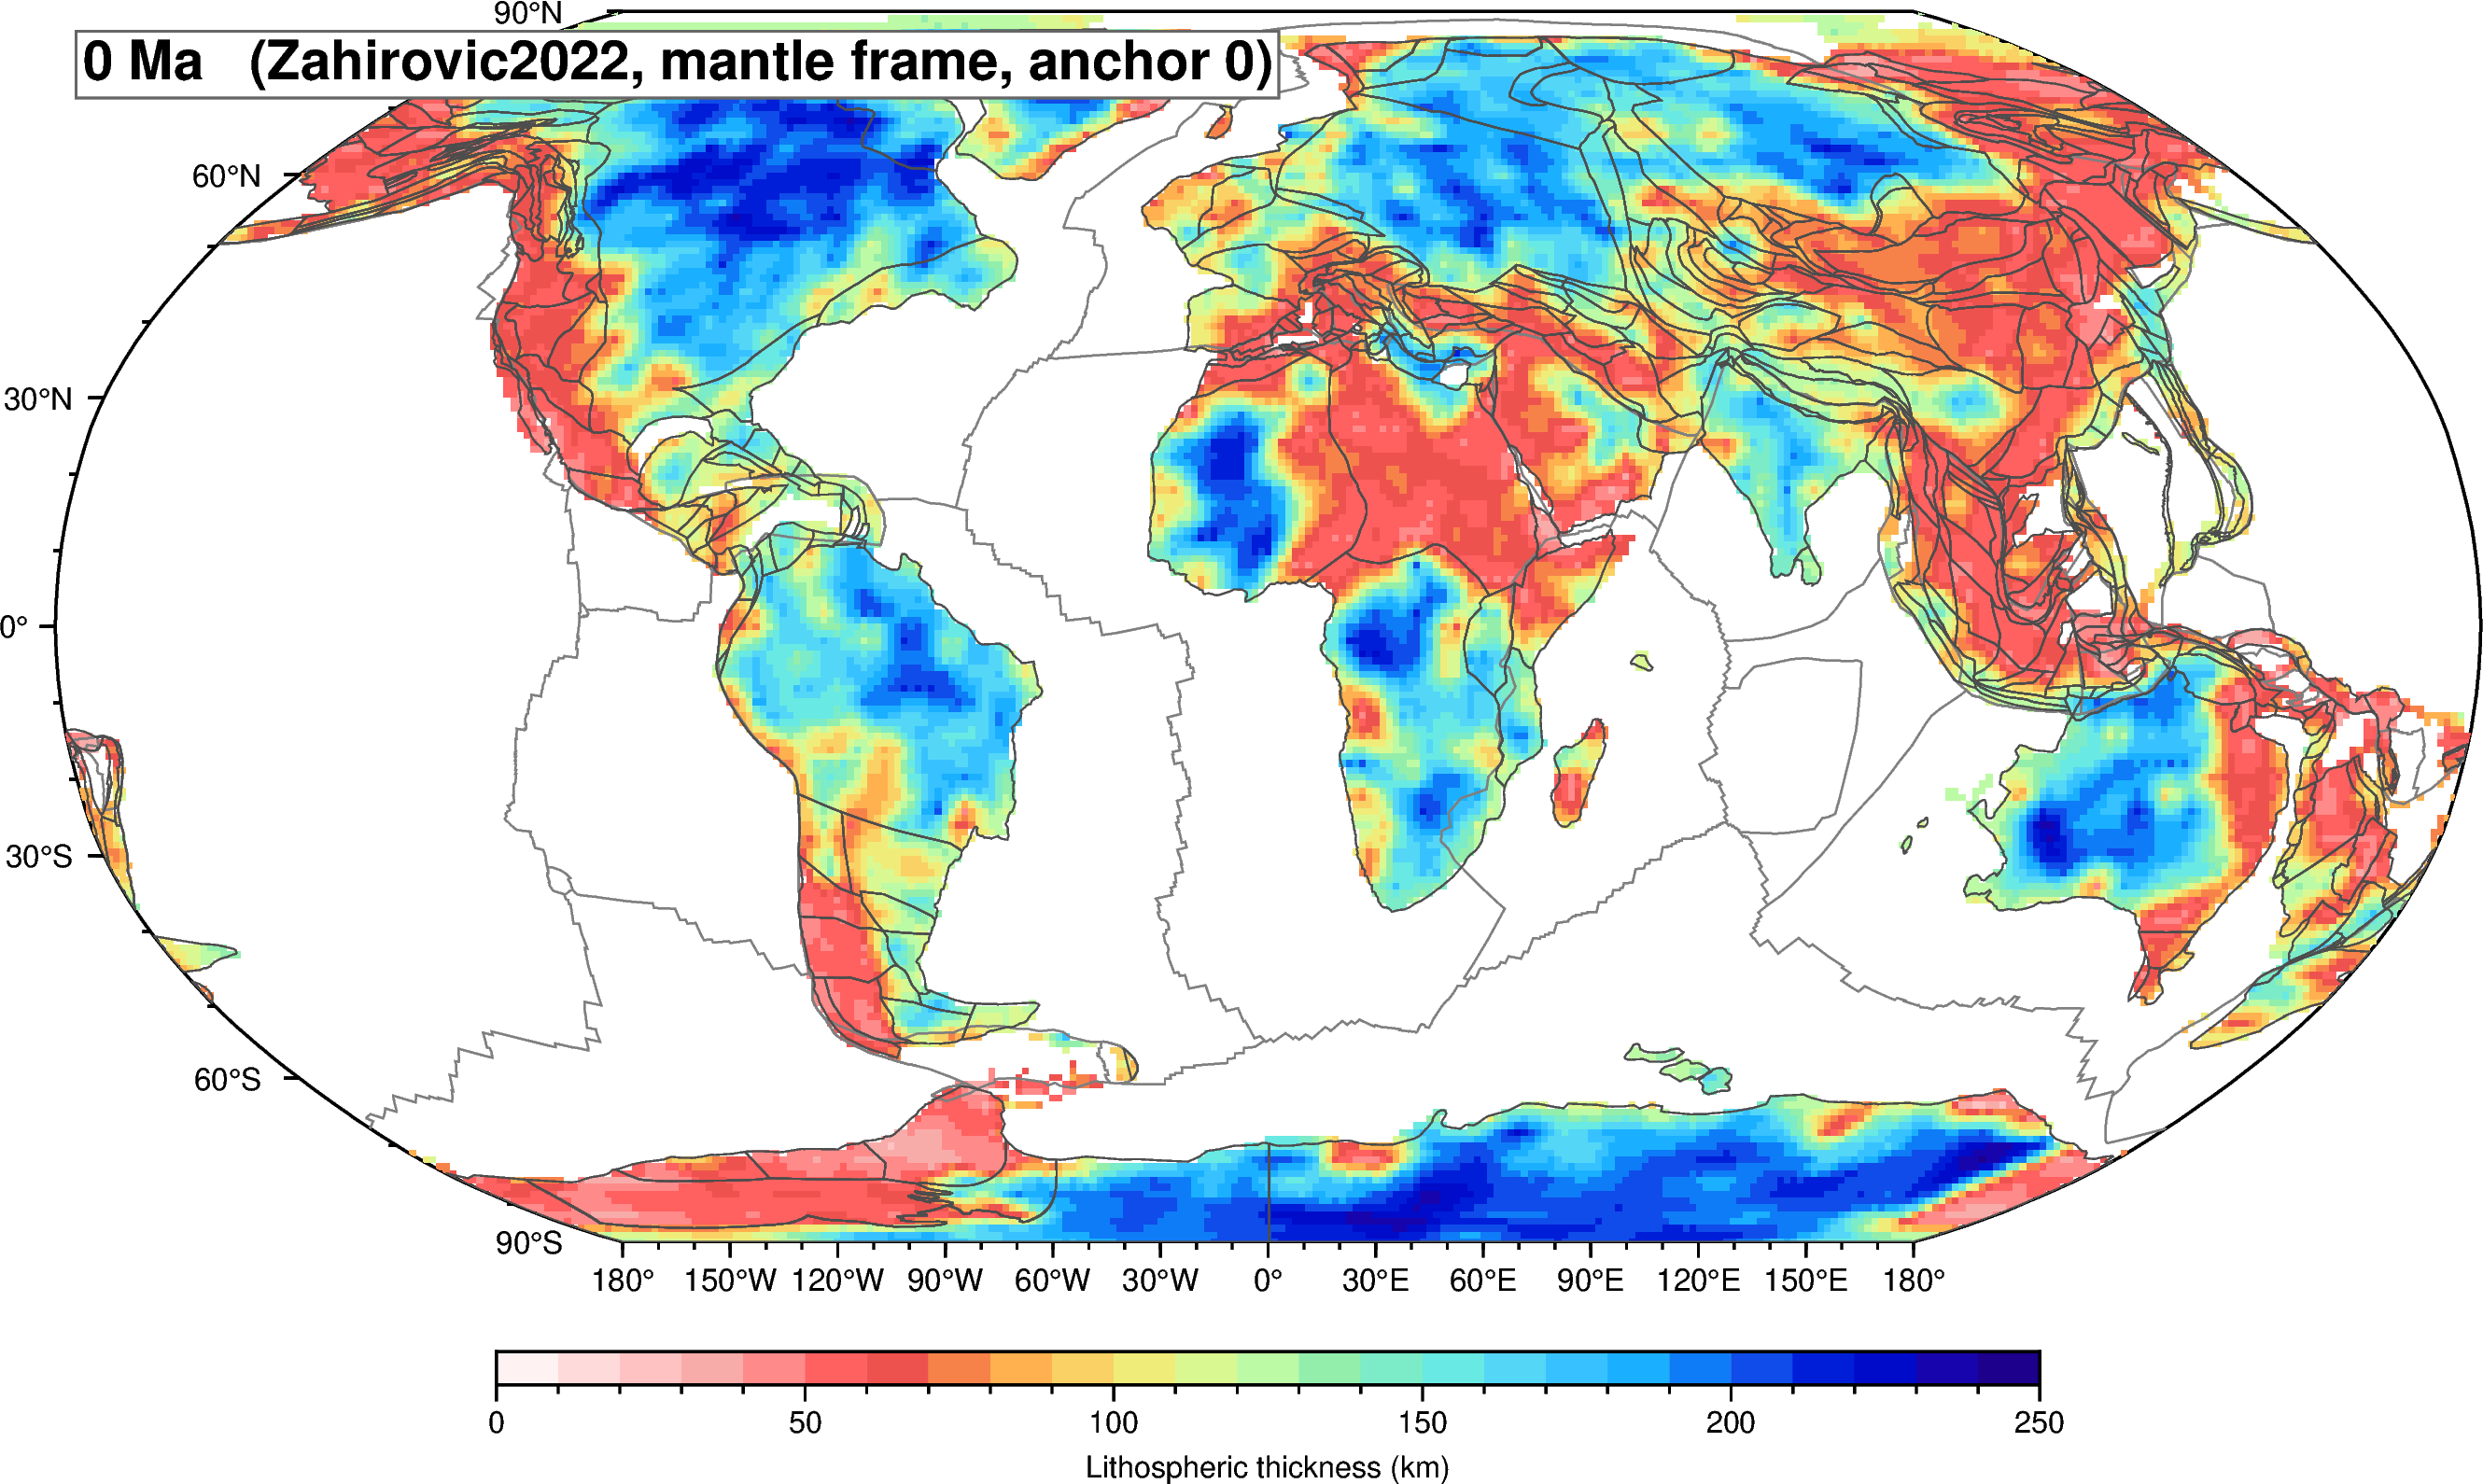

  rendering t=80 Ma  (grid range 10 – 250 km)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


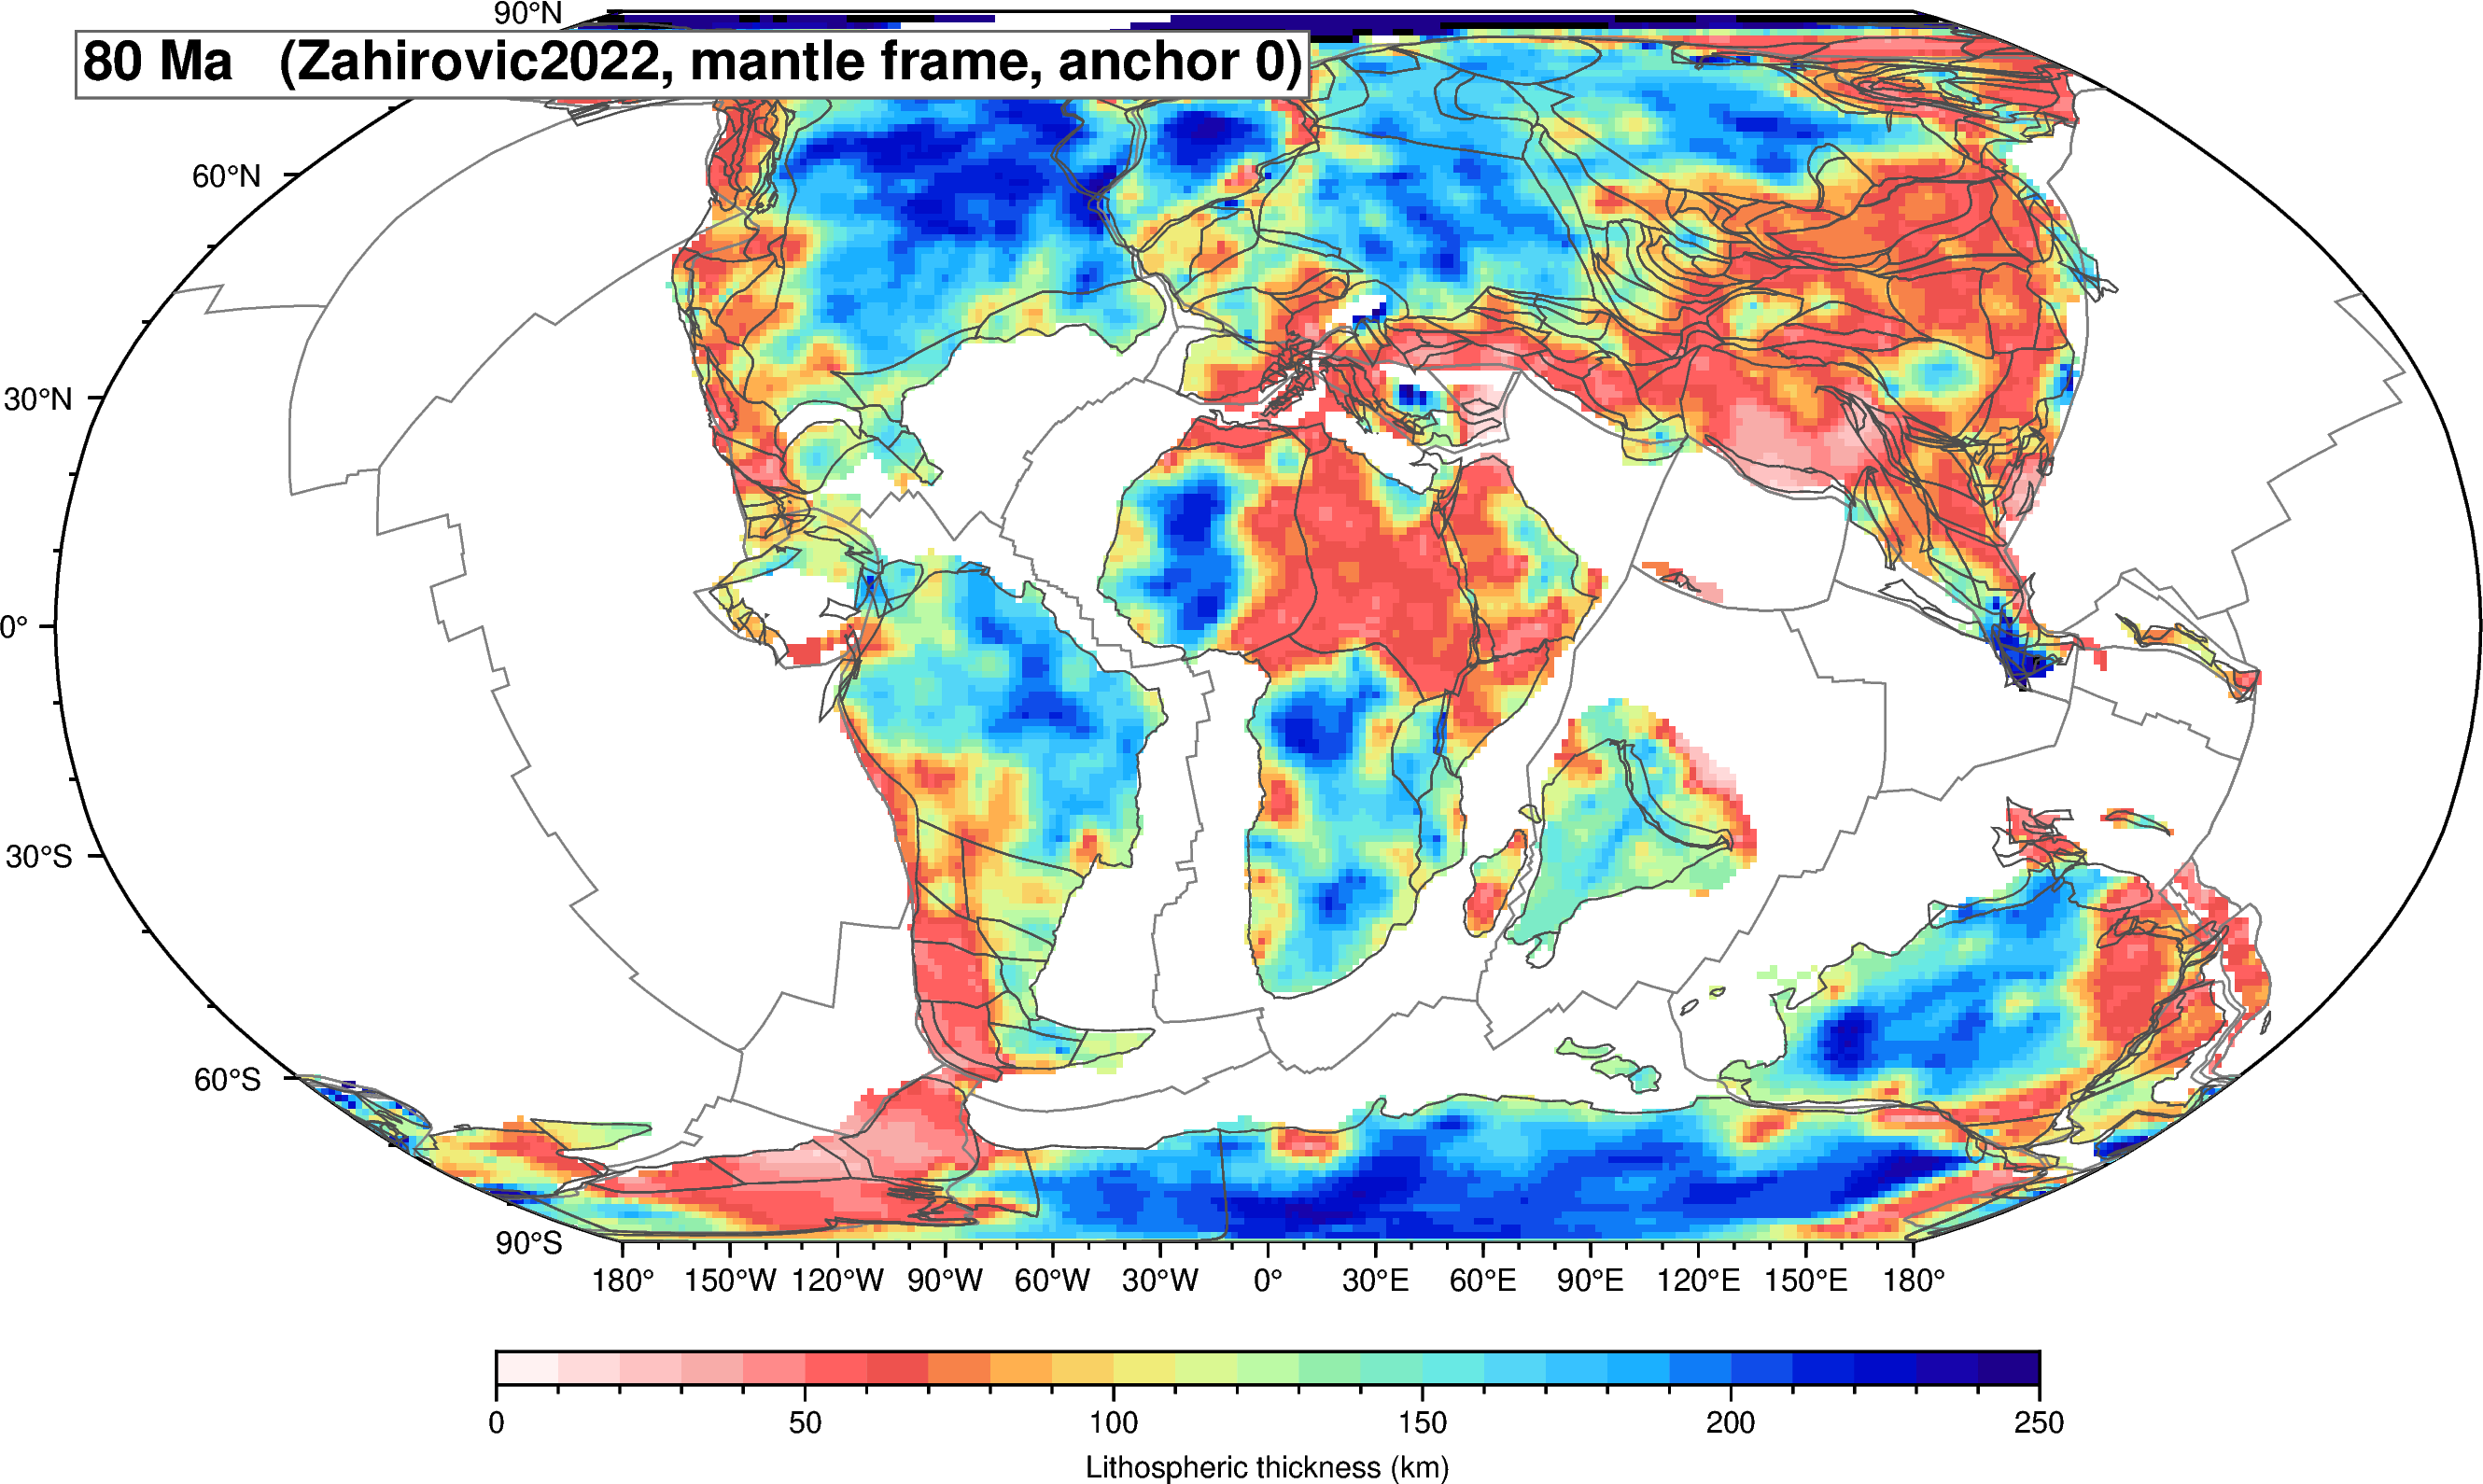

  rendering t=160 Ma  (grid range 10 – 250 km)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


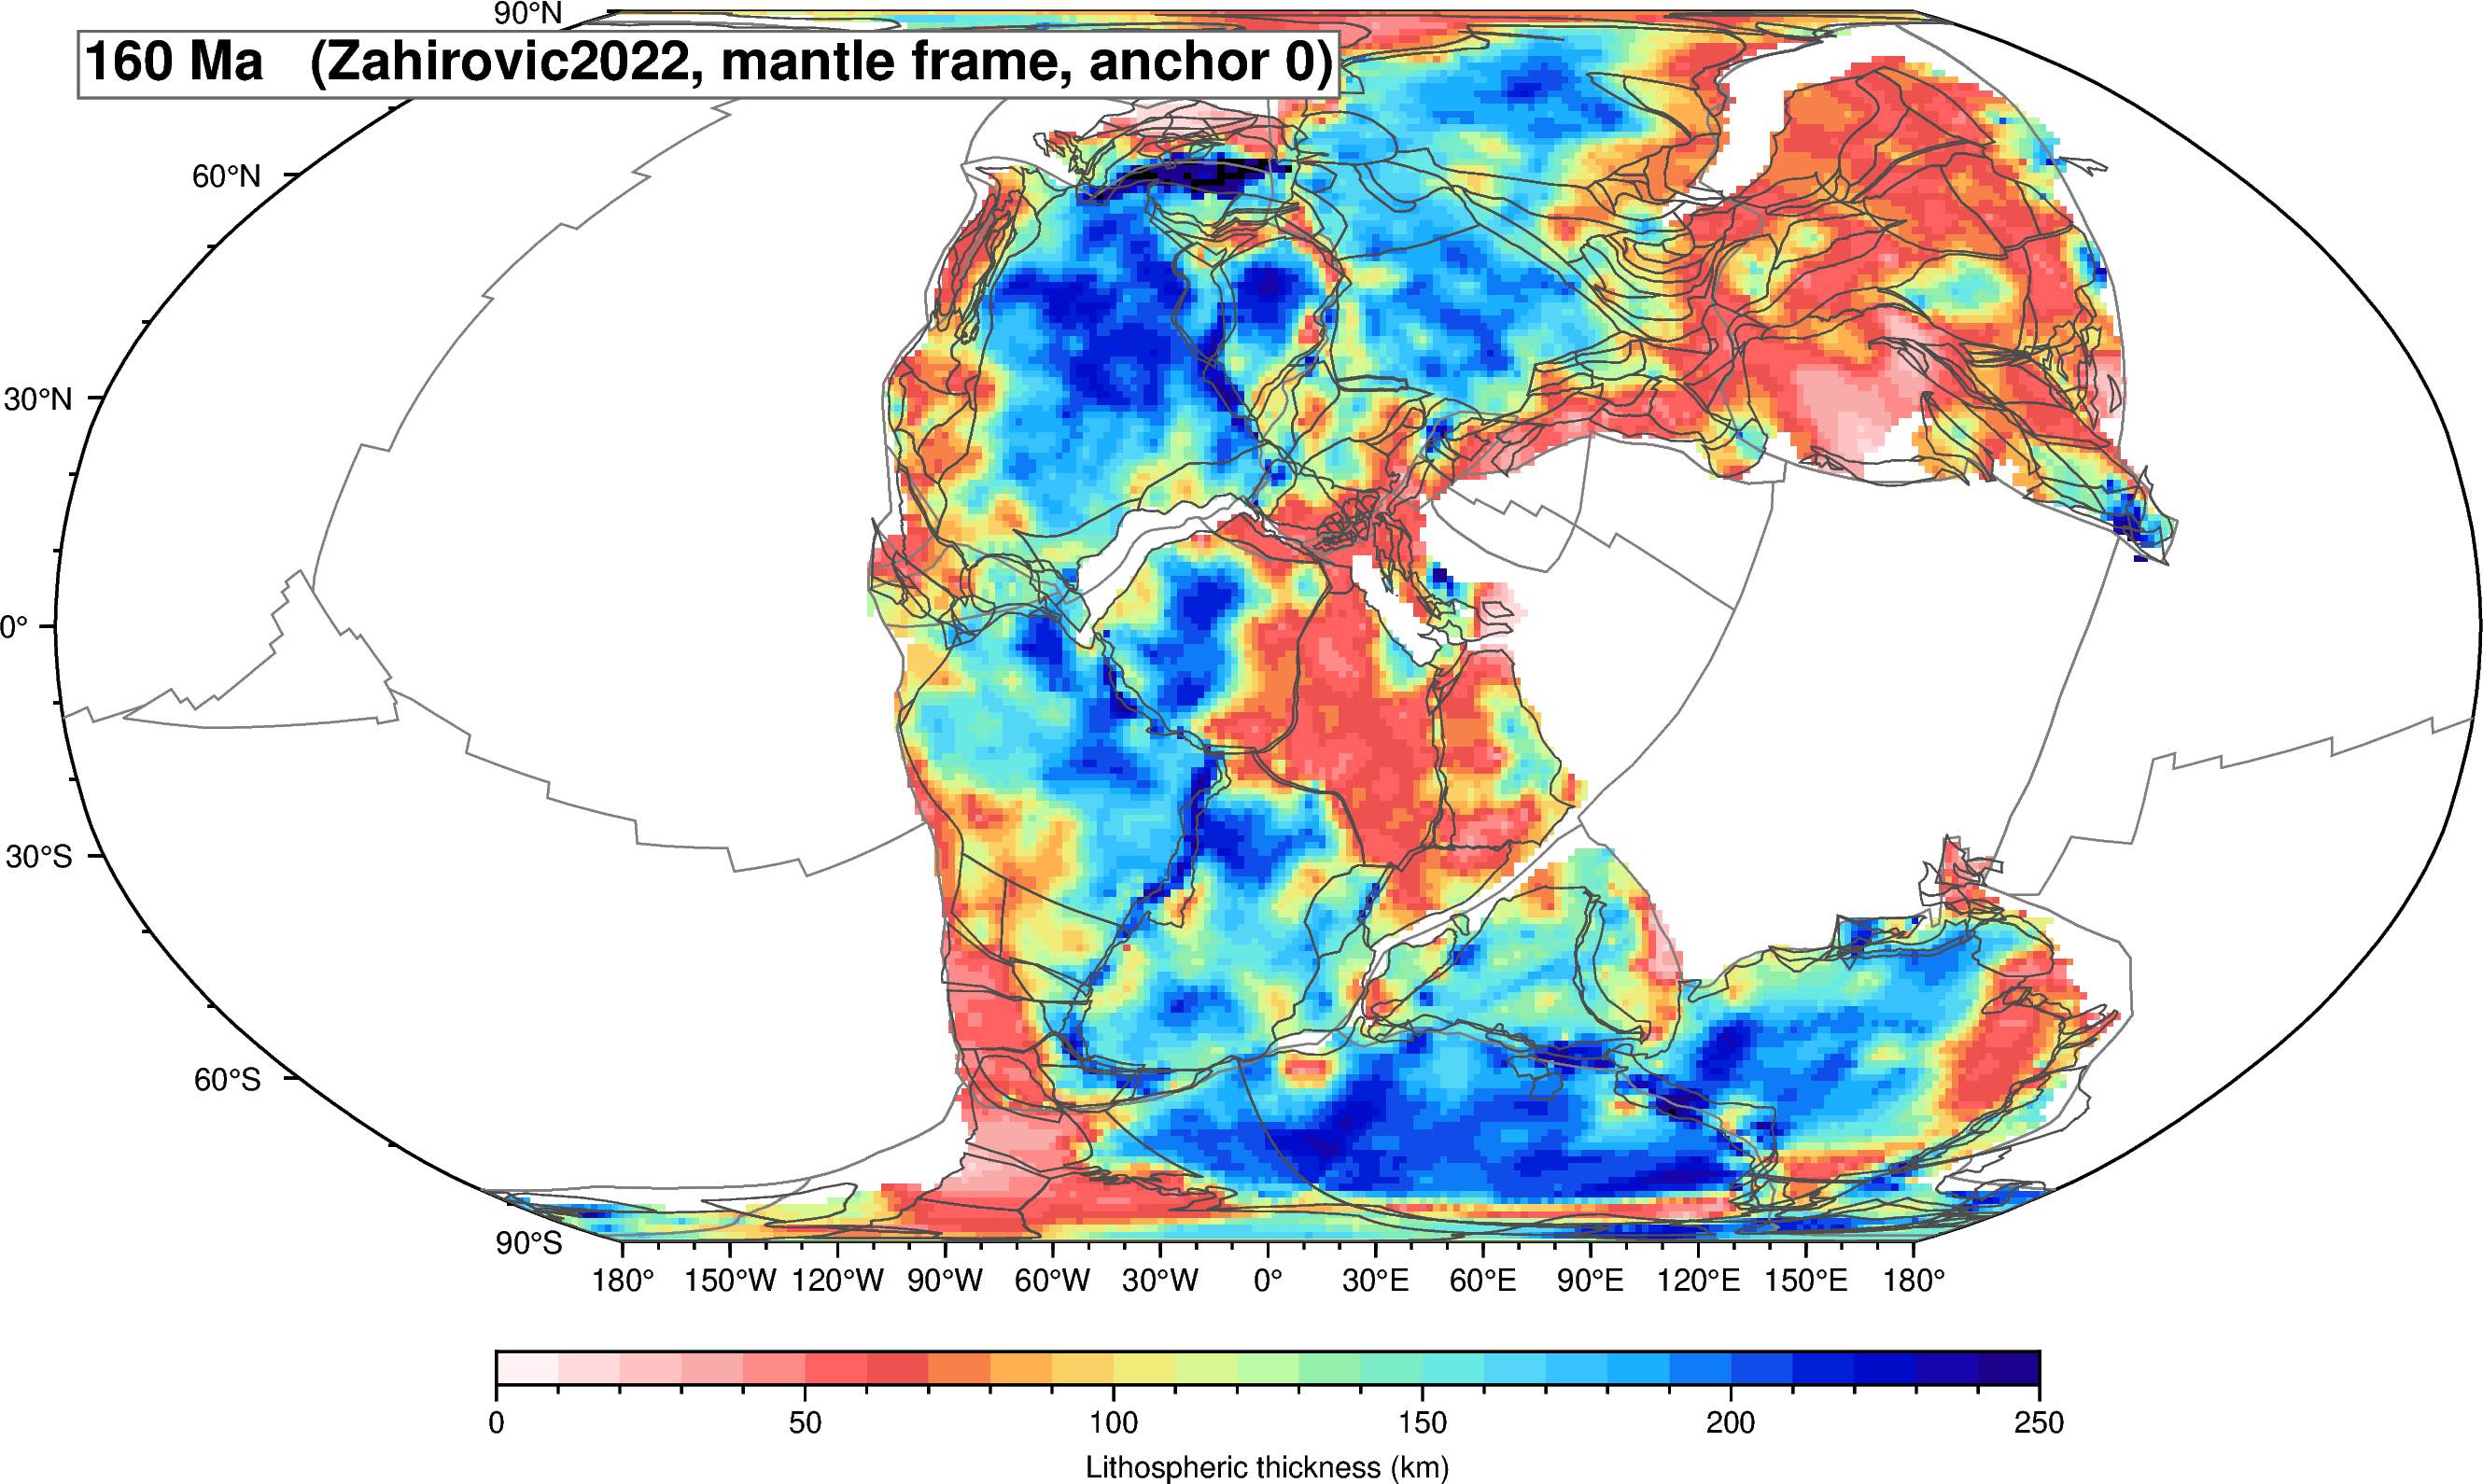

  rendering t=250 Ma  (grid range 10 – 250 km)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


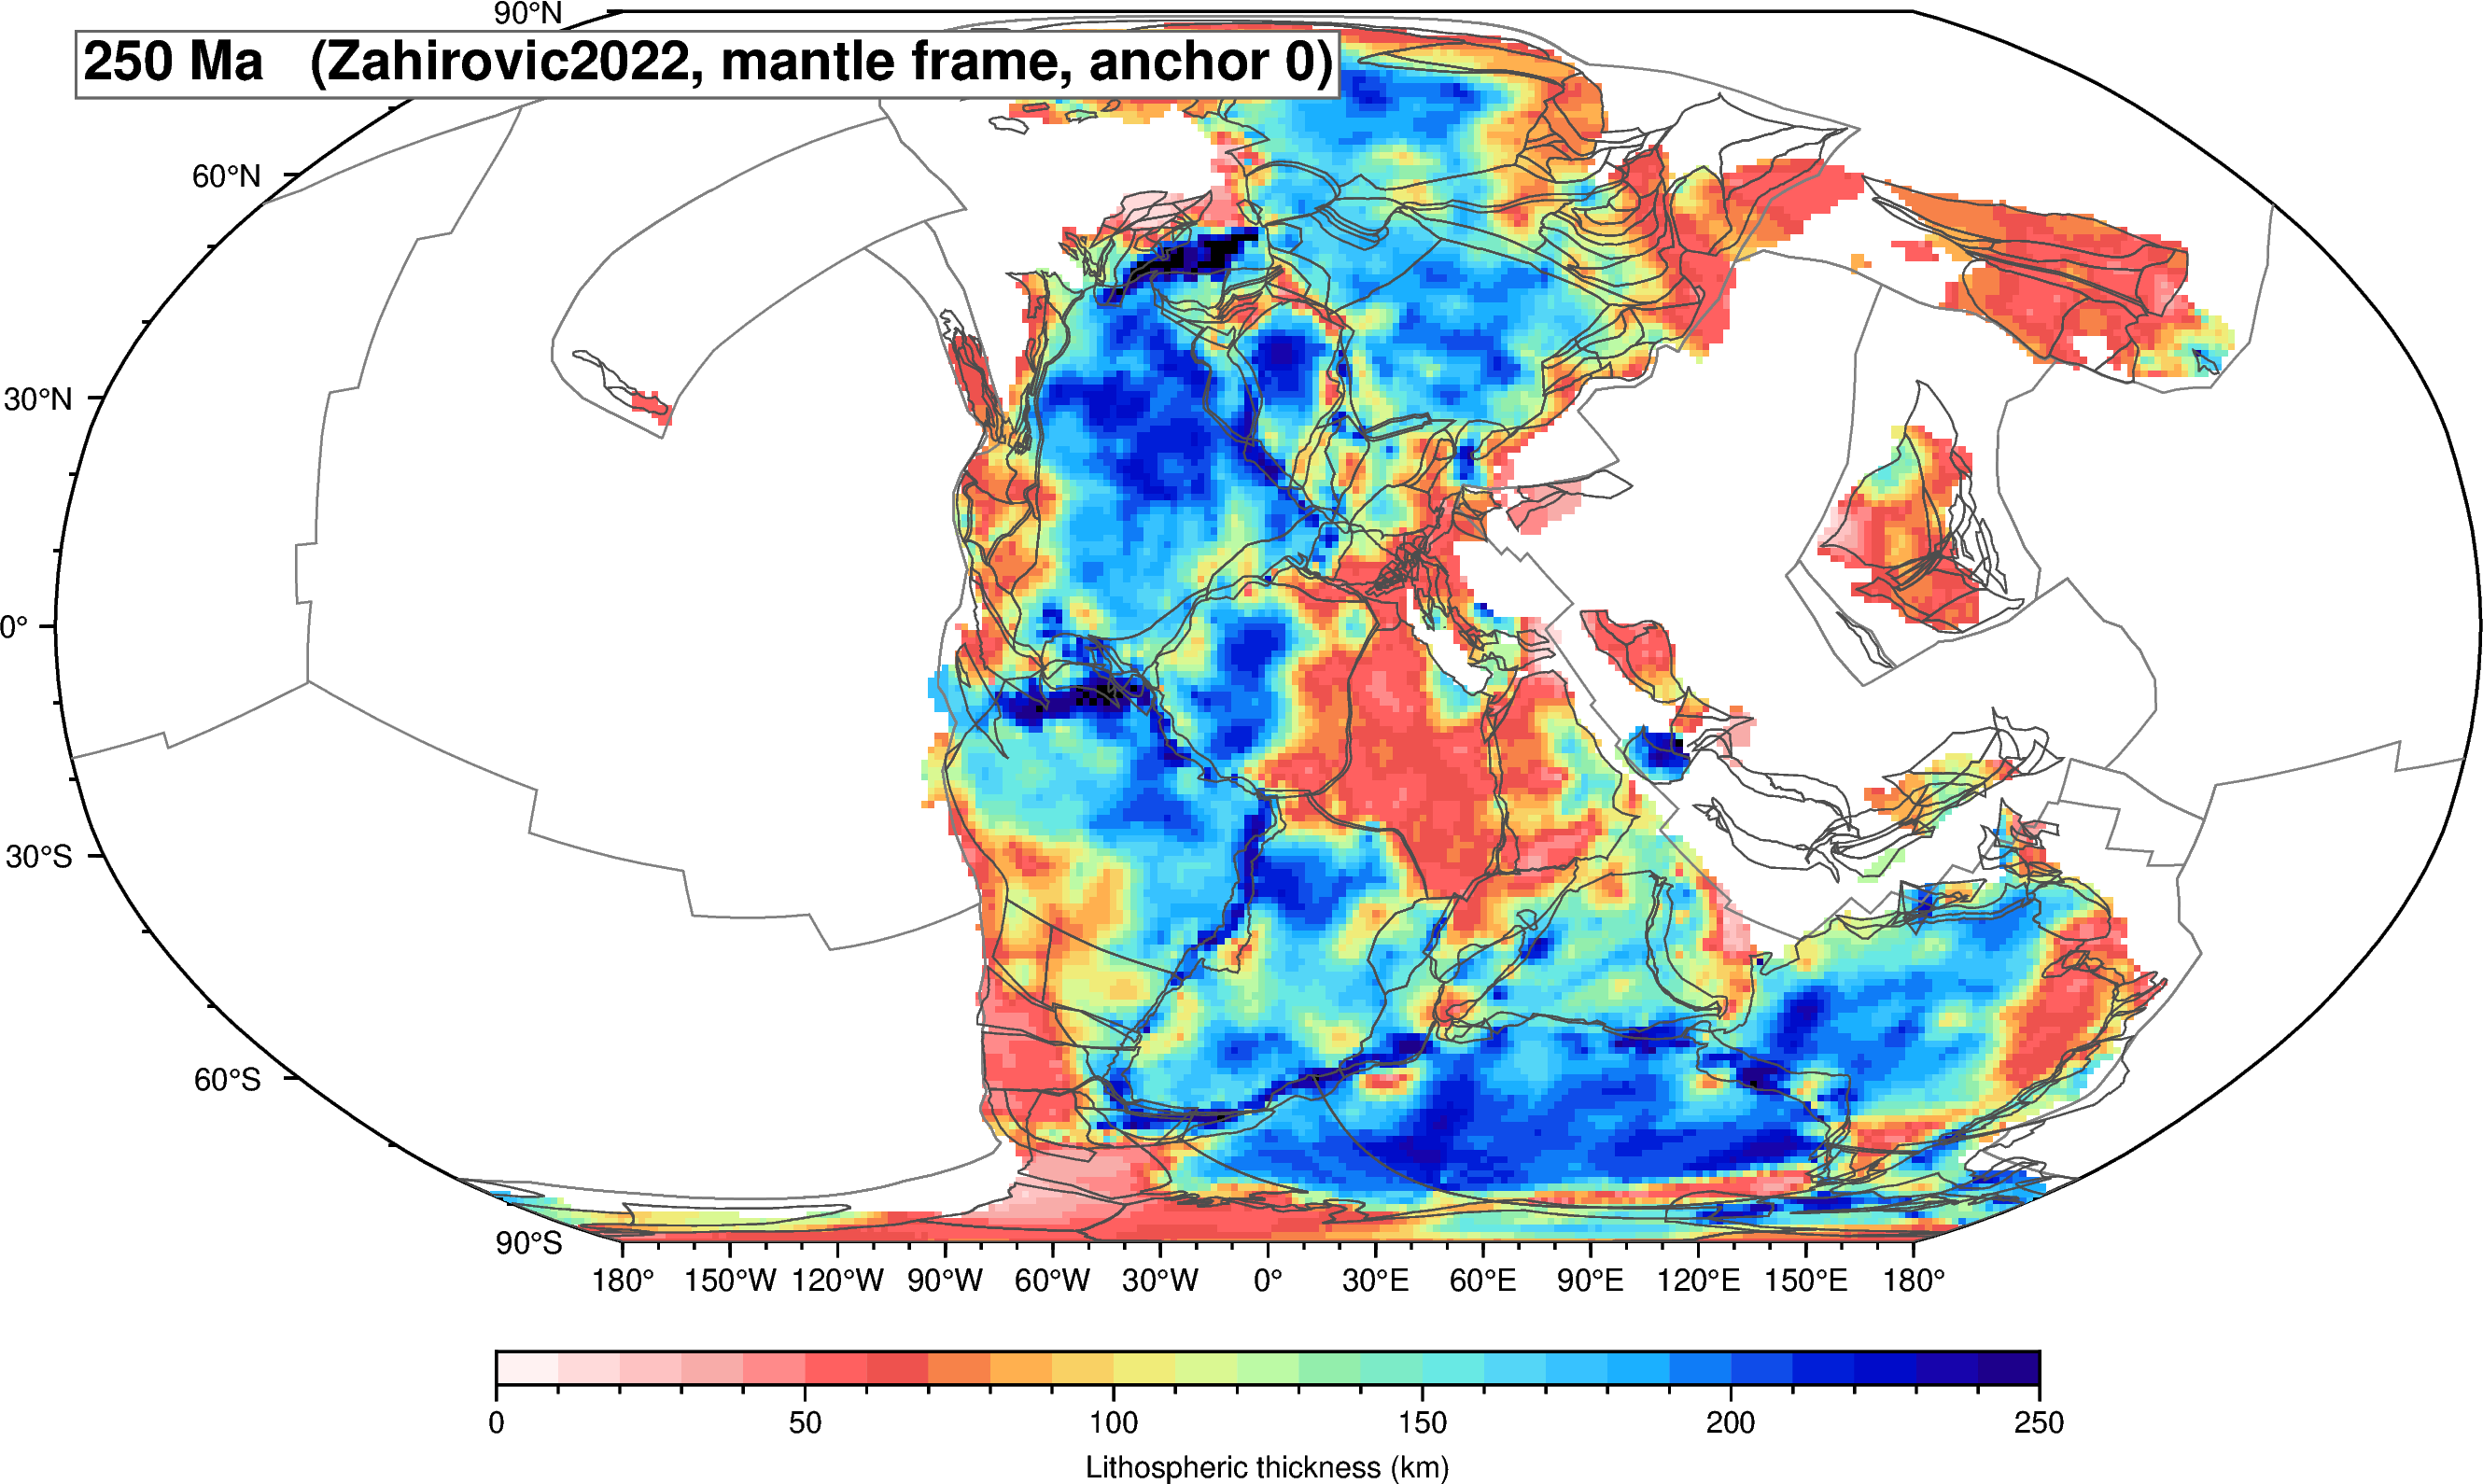

In [9]:
# Cell 7 — snapshot pyGMT figure series (one Figure() per snapshot, house style)

# Diagnostic — what's actually in paleo_grids?
print(f"  paleo_grids contains {len(paleo_grids)} snapshot(s):")
print(f"    keys: {sorted(float(k) for k in paleo_grids.keys())}")
print(f"    requested SNAPSHOT_TIMES_FIG: {list(SNAPSHOT_TIMES_FIG)}")

if not paleo_grids:
    raise RuntimeError(
        "paleo_grids is empty — section-3 (reconstruct) and section-4 (apply pure-shear) "
        "and section-5 (regrid + save NCs) must all have completed and populated the dict. "
        "Re-run those cells in order before this one.")

recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

pygmt.makecpt(cmap="haxby", series=[0, 250, 10], reverse=True)

# Tolerance-based lookup: match SNAPSHOT_TIMES_FIG to the nearest key in
# paleo_grids in case of dtype/precision drift (numpy.float64 vs Python float).
def _nearest_key(target, keys, tol=0.5):
    matches = [k for k in keys if abs(float(k) - float(target)) < tol]
    return matches[0] if matches else None

for t in SNAPSHOT_TIMES_FIG:
    key = _nearest_key(t, paleo_grids.keys())
    if key is None:
        print(f"  ⚠ skipping t={t} Ma — no paleo grid in memory")
        continue
    da = paleo_grids[key]
    print(f"  rendering t={float(key):.0f} Ma  (grid range {float(da.min()):.0f} – {float(da.max()):.0f} km)")

    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(key),
        plot_engine=gplately.PygmtPlotEngine(),
        )

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="N0/22c", frame=["af"])
    fig.grdimage(grid=da, cmap=True, nan_transparent=True)

    # Continuous-backbone plate-boundary pattern
    try:
        gplot.plot_all_topological_sections(fig, pen="0.5p,gray50")
    except Exception as e:
        print(f"    (skip backbone: {type(e).__name__})")

    # Continent outline (gray, no fill so the thickness raster shows through)
    try:
        gplot.plot_continents(fig, pen="0.4p,gray30", fill=None)
    except Exception as e:
        print(f"    (skip continent outline: {type(e).__name__})")

    fig.colorbar(position="JBC+w14c/0.3c+h+o0/1.0c",
                 frame=["af", "x+lLithospheric thickness (km)"])
    fig.text(text=f"{float(key):.0f} Ma   ({MODEL_NAME}, mantle frame, anchor {ANCHOR_PLATE_ID})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)
    display(HTML('<div style="height:0.8cm"></div>'))


## What this notebook produces

- **`outputs/paleo_lithospheric_thickness/paleo_LAB_<t>Ma.nc`** — a CF-compliant NetCDF for every snapshot in `TIME_RANGE_MA`, on a regular `OUTPUT_SPACING_DEG` lat/lon grid. Variable `lithospheric_thickness` in km. Metadata records the source grid, plate model, anchor plate, and the McKenzie-pure-shear assumption.
- **Four pyGMT triptych panels** showing the retrodeformed field at 0 / 80 / 160 / 250 Ma, with deforming-network outline (orange) and continent outlines (gray) overlaid.

## Caveats — read before using the output for science

1. **Mantle frame only.** These grids are in the no-net-rotation mantle reference frame (`ANCHOR_PLATE_ID = 0`). Do NOT compare them to paleomagnetic or paleoclimate proxies without rerunning with `ANCHOR_PLATE_ID = 701701`.
2. **McKenzie pure shear** is a first-order assumption. It assumes uniform vertical stretching with no asthenospheric inflow, no lower-crustal flow, and no surface erosion or sedimentation. In real rifts, the lithospheric mantle thins more than the crust ("non-uniform stretching"); in real orogens, erosion strips thickened crust on Myr timescales. Treat the output as the *kinematic-conservation prediction*, not the *true paleo-thickness*.
3. **Two-stage thickness clamping.** Deforming-mesh β can be unphysically large in extreme rifts/orogens — even a modest β = 3 on a cratonic root would predict ~750 km LAB thickness, which is geophysically impossible. We apply (a) a ratio clamp `det F ∈ [0.2, 3]` as a secondary guard against pure-shear amplification, and (b) an absolute thickness clamp `OUTPUT_THICKNESS_CLAMP_KM = (10, 320)` as the primary physical cap. In regions where either clamp is active the output is a placeholder, not a quantitative thickness estimate. Tweak both knobs in the CONFIGURATION cell.
4. **0–250 Ma scope by default.** Z22's deforming networks only cover 0–250 Ma so the default `TIME_RANGE_MA` matches that window. Past 250 Ma there is no further deformation to track — the converged 250 Ma deformed state just rigidly rotates with its plate IDs. We expose this as an *Extend this* option rather than the default to keep the headline workflow focused on what Z22 actually constrains. To go past 410 Ma at all you need a different rotation model (Merdith 2021 covers 0–1000 Ma).
5. **Oceanic crust is excluded.** Output is NaN everywhere over present-day oceans. This keeps the notebook focused on the actual deformation story (continental rifts, orogens, and the strain captured by Z22's deforming meshes). For mantle-model use you typically also need oceanic LAB thickness — see *Extend this* for how to overlay half-space cooling `h(age) ≈ 11√age km` based on the past-time AgeGrid.
6. **All continental points are kept through every snapshot.** We override pygplates' `DefaultDeactivatePoints` with a `_KeepAllPoints` subclass that never deactivates — without this the default subduction-style rule (designed for forward reconstruction) would kill huge swaths of continental crust going backward through plate-boundary transitions, leaving large NaN holes in the continental output. The trade-off: an artefact in the deforming-mesh kinematics (e.g. a point briefly transiting an oceanic plate before re-entering a continent) is now silently preserved; if a snapshot looks suspect at a particular margin, that's where to look.

## Extend this

- **Add oceanic crust via half-space cooling.** Drop the `continental` mask in cell 3 and the `continental_mask` step in cell 6; then, after regridding, fill cells that have NaN but whose past-time PMM AgeGrid has a finite age with the half-space cooling thickness `h(age) ≈ 11√age km` (capped at ~130 km, Stein & Stein 1992). For the past-time AgeGrid, call the bundled `_open_age_grid(model, float(t))` helper that already lives in cell 3. This is what you want as a complete mantle-model boundary condition; the headline workflow keeps continents-only to stay focused on the kinematic-deformation story.
- **Switch to the paleomag frame.** Set `ANCHOR_PLATE_ID = 701701` and rerun — outputs become directly comparable to paleomag-based reconstructions and paleoclimate proxies.
- **Extend past 250 Ma — rigid transport of the deformed state.** Change `TIME_RANGE_MA` to `(0.0, 410.0, 10.0)`. Past 250 Ma `pygplates` will no longer add any new strain — `get_crustal_thicknesses(t > 250 Ma)` returns the same retrodeformed thickness as at 250 Ma, transported rigidly via plate IDs to its older paleo-position. Add a 400 Ma entry to `SNAPSHOT_TIMES_FIG` to render it.
- **Switch to reconstructing crustal thickness instead of lithospheric thickness.** Crustal-thickness grids from the same Afonso et al. (2019, *Geophysical Journal International*) inversion are available at <https://www.earthbyte.org/webdav/ftp/earthbyte/gplates_portal/Afonso_etal_lithospheric_thickness_GJI2019/>. Point `SOURCE_GRID` at the relevant NetCDF and adjust `OUTPUT_THICKNESS_CLAMP_KM` to a physically defensible crustal-thickness range (~5–70 km, with thick orogens reaching ~70 km, thin oceanic crust ~5 km). The McKenzie pure-shear retrodeformation pipeline works identically for either thickness scalar. Note also that two alternative re-interpolations of the original (relatively coarse) Afonso grids are bundled at the same URL, both at a finer 0.1° resolution — one produced via surface-spline interpolation and the other via nearest-neighbour interpolation; the spline variant is smoother but can overshoot at sharp continent/ocean transitions, while the nearest-neighbour variant preserves the original-grid edge sharpness at the cost of stair-stepping in highly oblique cells.
- **Animate.** Convert the 26-snapshot NC stack into an MP4 via the same pattern as T06 (Animations) — useful for talks and for visually validating the retrodeformation.

## References

- Afonso, J.C., Salajegheh, F., Szwillus, W., Ebbing, J., Gaina, C. (2019). A global reference model of the lithosphere and upper mantle from joint inversion and analysis of multiple data sets. *Tectonophysics* 757, 198-215.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371–383. https://doi.org/10.1002/gdj3.146
- McKenzie, D.P. (1978). Some remarks on the development of sedimentary basins. *Earth and Planetary Science Letters* 40, 25-32.
- Müller, R.D. et al. (2018). GPlates — building a virtual Earth through deep time. *Geochemistry, Geophysics, Geosystems* 19, 2243-2261.
- Mather, B.R. et al. (2024). GPlately. *GDJ* 11, 3-10.
- Tian, D. et al. (2024). PyGMT. *Zenodo*.
